# Ola Ride Analytics – Python EDA
**Dataset:** Ola Bookings (103,024 rows 20 columns)
**Goal:** Exploratory Data Analysis, Business KPIs, Statistical Tests & Actionable Insights

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

## Load & First Look

In [2]:
df = pd.read_csv("Bookings.csv")

# Drop the broken image column and the unnamed trailing column
df.drop(columns=['Vehicle Images', 'Unnamed: 20'], inplace=True, errors='ignore')

# Parse datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

print(f"Shape: {df.shape}")
df.head()

Shape: (103024, 19)


,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   object        
 11  Canceled_Rides_by_Driver    18434 non-n

In [4]:
df.describe(include='all')

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating
count,103024,103024,103024,103024,103024,103024,103024,103024,63967.000000,63967.000000,10499,18434,63967,3926,103024.000000,63967,103024.000000,63967.000000,63967.000000
unique,NaN,1440,103024,4,94544,7,50,50,NaN,NaN,5,4,2,3,NaN,4,NaN,NaN,NaN
top,NaN,00:53:00,CNR7153255142,Success,CID954071,Prime Sedan,Banashankari,Peenya,NaN,NaN,Driver is not moving towards pickup location,Personal & Car related issue,No,Customer Demand,NaN,Cash,NaN,NaN,NaN
freq,NaN,101,1,63967,5,14877,2201,2159,NaN,NaN,3175,6542,60041,1601,NaN,35022,NaN,NaN,NaN
mean,2024-07-16 11:31:38.879678720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.876952,84.873372,NaN,NaN,NaN,NaN,548.751883,NaN,14.189927,3.997457,3.998313
min,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,25.000000,NaN,NaN,NaN,NaN,100.000000,NaN,0.000000,3.000000,3.000000
25%,2024-07-08 18:41:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,55.000000,NaN,NaN,NaN,NaN,242.000000,NaN,0.000000,3.500000,3.500000
50%,2024-07-16 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168.000000,85.000000,NaN,NaN,NaN,NaN,386.000000,NaN,8.000000,4.000000,4.000000
75%,2024-07-24 05:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,238.000000,115.000000,NaN,NaN,NaN,NaN,621.000000,NaN,26.000000,4.500000,4.500000
max,2024-07-31 23:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,308.000000,145.000000,NaN,NaN,NaN,NaN,2999.000000,NaN,49.000000,5.000000,5.000000


## Data Quality Check

In [5]:
# Missing values per column
missing = df.isna().sum().sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})[missing > 0]

,Missing Count,Missing %
Incomplete_Rides_Reason,99098,96.19
Canceled_Rides_by_Customer,92525,89.81
Canceled_Rides_by_Driver,84590,82.11
Driver_Ratings,39057,37.91
Incomplete_Rides,39057,37.91
C_TAT,39057,37.91
V_TAT,39057,37.91
Payment_Method,39057,37.91
Customer_Rating,39057,37.91


In [6]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Booking_Value = 0 on cancelled rides (expected) - verify
print("\nMin Booking_Value:", df['Booking_Value'].min())
print("Rows with Booking_Value=0:", (df['Booking_Value']==0).sum())

Duplicate rows: 0

Min Booking_Value: 100
Rows with Booking_Value=0: 0


In [7]:
df['Hour'] = df['Date'].dt.hour

# Key insight comment
# Columns like Driver_Ratings, Customer_Rating, V_TAT, C_TAT are NULL for non-successful rides - this is EXPECTED.
# We will handle NULLs contextually (e.g., only analyse ratings on successful rides).
successful = df[df['Booking_Status'] == 'Success'].copy()
print(f"Successful rides: {len(successful):,}  ({len(successful)/len(df)*100:.1f}% of total)")

Successful rides: 63,967  (62.1% of total)


## Key Performance Indicators (KPIs)

In [8]:
kpi = {
    'Total Bookings'       : len(df),
    'Successful Rides'     : (df['Booking_Status']=='Success').sum(),
    'Booking Success Rate' : f"{(df['Booking_Status']=='Success').mean()*100:.2f}%",
    'Total Revenue (INR)'  : f"₹{df.loc[df['Booking_Status']=='Success','Booking_Value'].sum():,.0f}",
    'Avg Booking Value'    : f"₹{df.loc[df['Booking_Status']=='Success','Booking_Value'].mean():.2f}",
    'Avg Ride Distance'    : f"{df.loc[df['Booking_Status']=='Success','Ride_Distance'].mean():.2f} km",
    'Avg Driver Rating'    : f"{successful['Driver_Ratings'].mean():.2f}",
    'Avg Customer Rating'  : f"{successful['Customer_Rating'].mean():.2f}",
}

for k, v in kpi.items():
    print(f"  {k:<28}: {v}")

  Total Bookings              : 103024
  Successful Rides            : 63967
  Booking Success Rate        : 62.09%
  Total Revenue (INR)         : ₹35,080,467
  Avg Booking Value           : ₹548.42
  Avg Ride Distance           : 22.85 km
  Avg Driver Rating           : 4.00
  Avg Customer Rating         : 4.00


## Booking Status Distribution

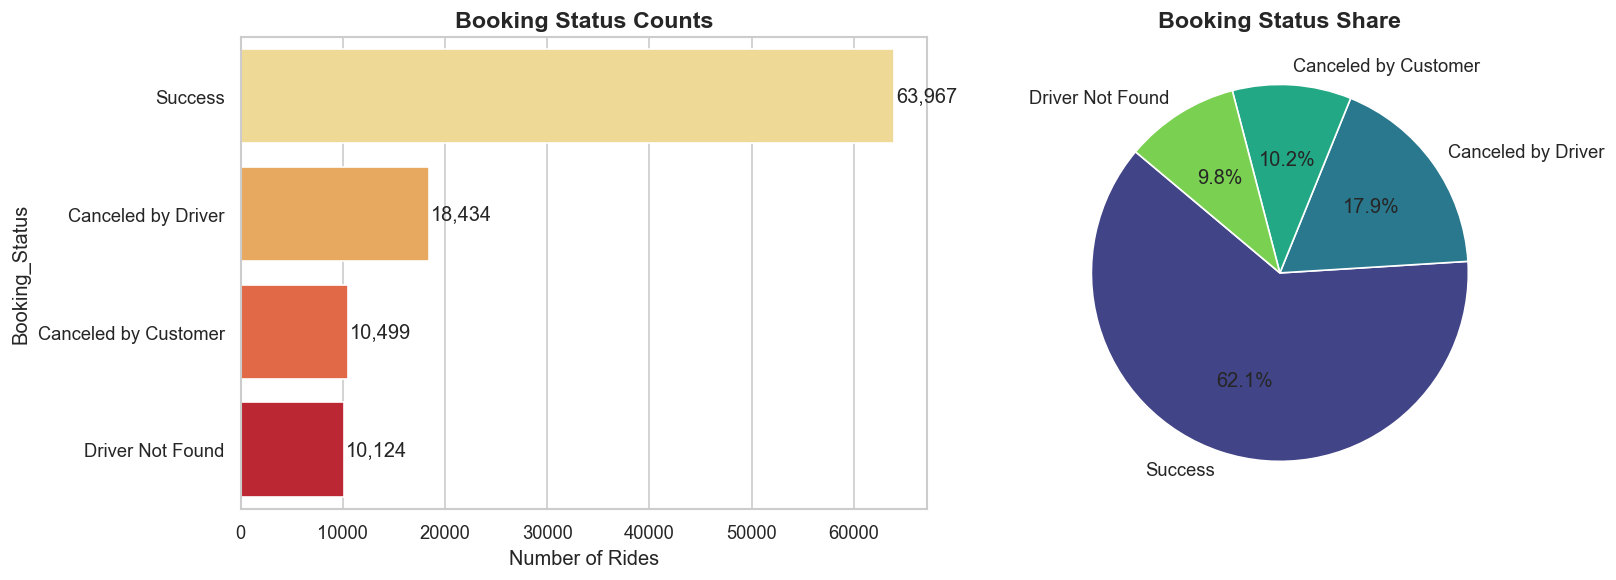


💡 Insight: ~62% of rides succeed. ~18% are cancelled by drivers — a major operational leak.


In [26]:
status_counts = df['Booking_Status'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax, palette='YlOrRd', hue=status_counts.index, legend=False)
ax.set_title('Booking Status Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Rides')
for i, v in enumerate(status_counts.values):
    ax.text(v + 200, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()


## Cancellation Deep Dive

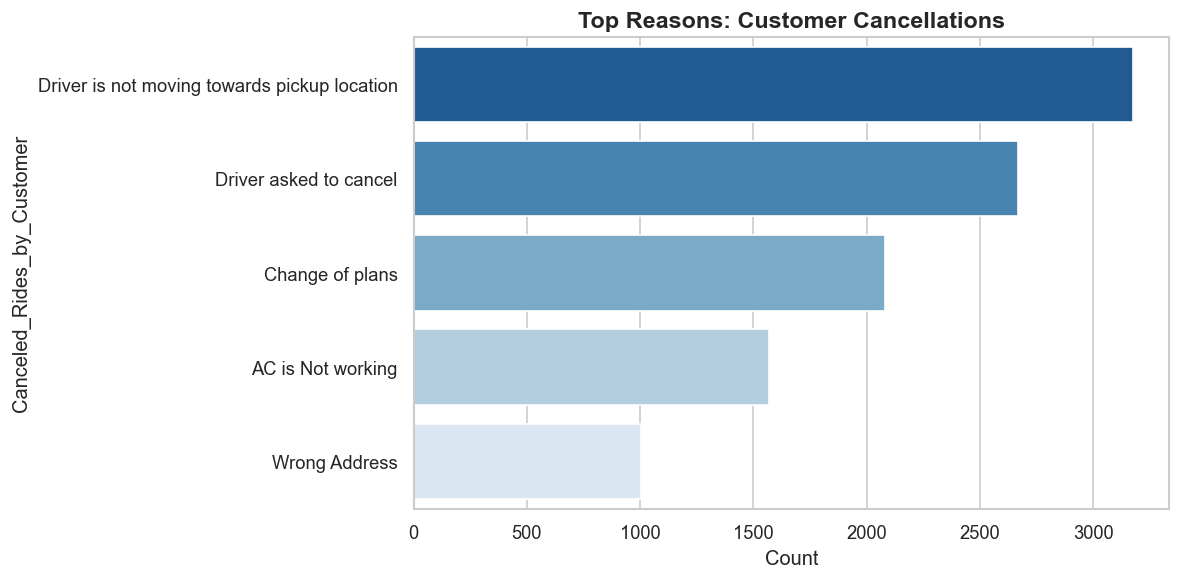

In [27]:
# By Customer
cust_cancel = df['Canceled_Rides_by_Customer'].dropna().value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_cancel.values, y=cust_cancel.index, hue=cust_cancel.index, palette='Blues_r', legend=False)
plt.title('Top Reasons: Customer Cancellations', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

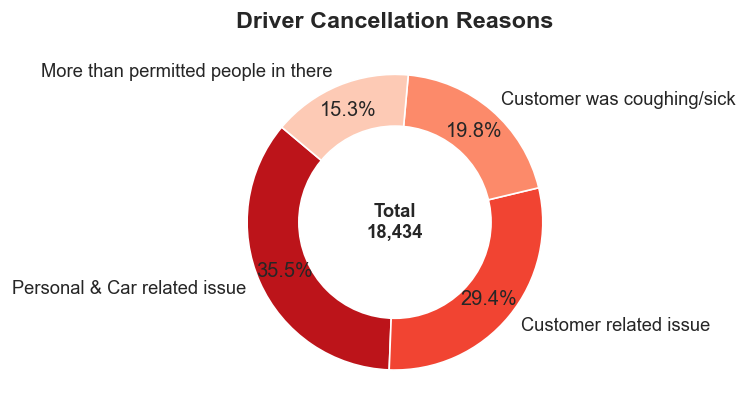


💡 Insight: 'Personal & Car related issue' is the #1 driver cancellation cause — vehicle maintenance incentives could reduce this.


## Vehicle Type Performance

In [29]:
veh_stats = df[df['Booking_Status']=='Success'].groupby('Vehicle_Type').agg(
    Total_Rides=('Booking_ID', 'count'),
    Avg_Booking_Value=('Booking_Value', 'mean'),
    Total_Revenue=('Booking_Value', 'sum'),
    Avg_Ride_Distance=('Ride_Distance', 'mean'),
    Avg_Driver_Rating=('Driver_Ratings', 'mean'),
    Avg_Customer_Rating=('Customer_Rating', 'mean'),
).round(2).sort_values('Total_Revenue', ascending=False)

veh_stats

,Total_Rides,Avg_Booking_Value,Total_Revenue,Avg_Ride_Distance,Avg_Driver_Rating,Avg_Customer_Rating
Vehicle_Type,,,,,,
Prime Sedan,9379,556.99,5224050,25.01,3.99,4.00
eBike,9180,550.62,5054662,25.15,4.01,3.99
Auto,9167,551.09,5051846,10.04,4.00,4.00
Prime Plus,9075,552.64,5015165,25.03,4.00,4.01
Bike,9134,544.34,4971968,24.93,3.98,3.99
Mini,9036,540.72,4885961,24.98,3.99,4.00
Prime SUV,8996,542.11,4876815,24.88,4.01,4.00


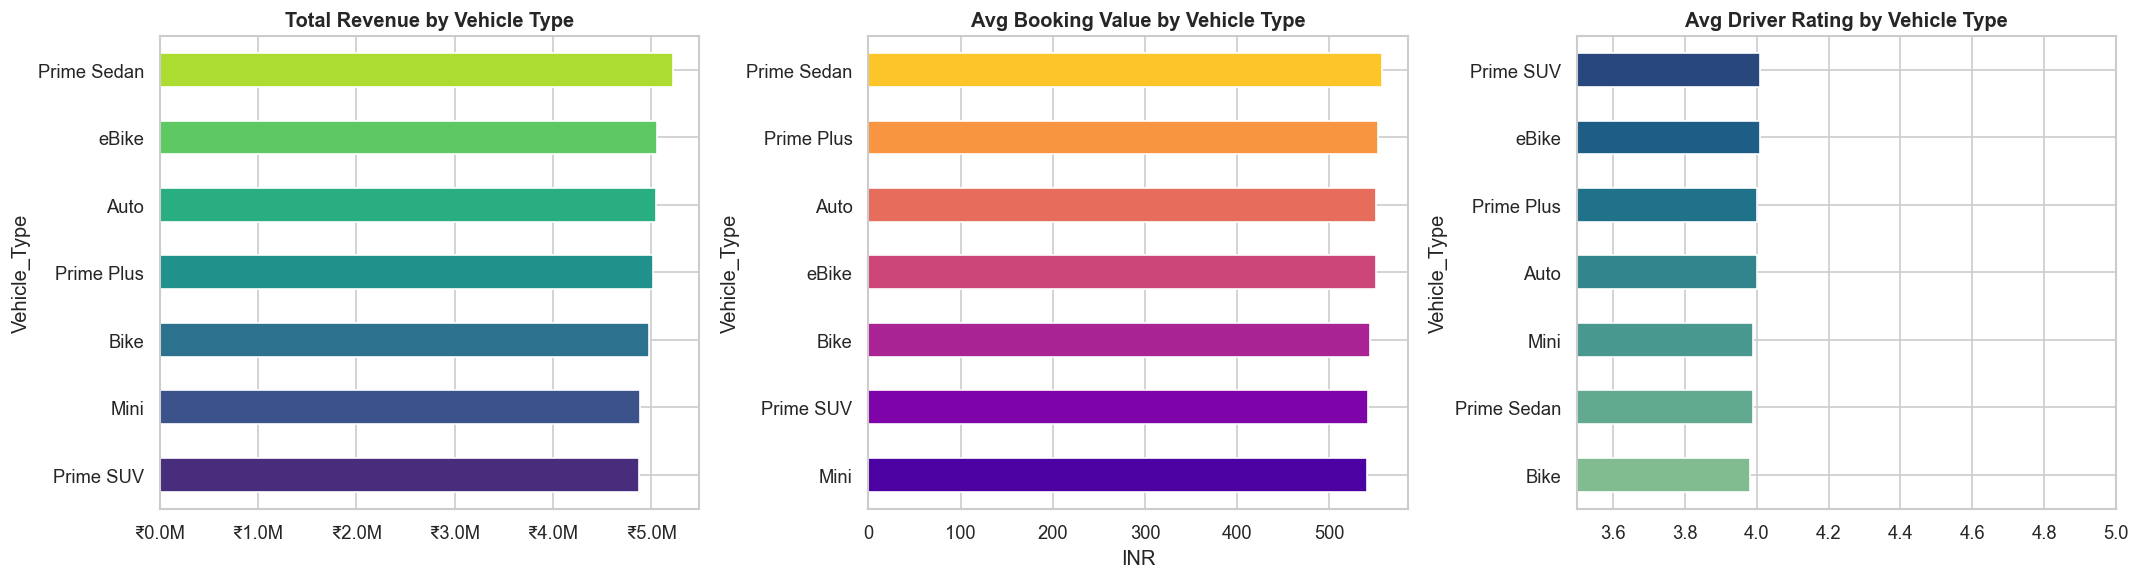


💡 Insight: Prime SUV and Prime Sedan generate the highest revenue per ride. eBike has the highest volume.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

veh_rev = veh_stats['Total_Revenue'].sort_values()
veh_rev.plot.barh(ax=axes[0], color=sns.color_palette('viridis', len(veh_rev)))
axes[0].set_title('Total Revenue by Vehicle Type', fontweight='bold')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[0].set_xlabel('')

veh_stats['Avg_Booking_Value'].sort_values().plot.barh(ax=axes[1], color=sns.color_palette('plasma', len(veh_stats)))
axes[1].set_title('Avg Booking Value by Vehicle Type', fontweight='bold')
axes[1].set_xlabel('INR')

veh_stats['Avg_Driver_Rating'].sort_values().plot.barh(ax=axes[2], color=sns.color_palette('crest', len(veh_stats)))
axes[2].set_title('Avg Driver Rating by Vehicle Type', fontweight='bold')
axes[2].set_xlim(3.5, 5)

plt.tight_layout()
plt.show()

print("\n💡 Insight: Prime SUV and Prime Sedan generate the highest revenue per ride. eBike has the highest volume.")

## Payment Method Analysis

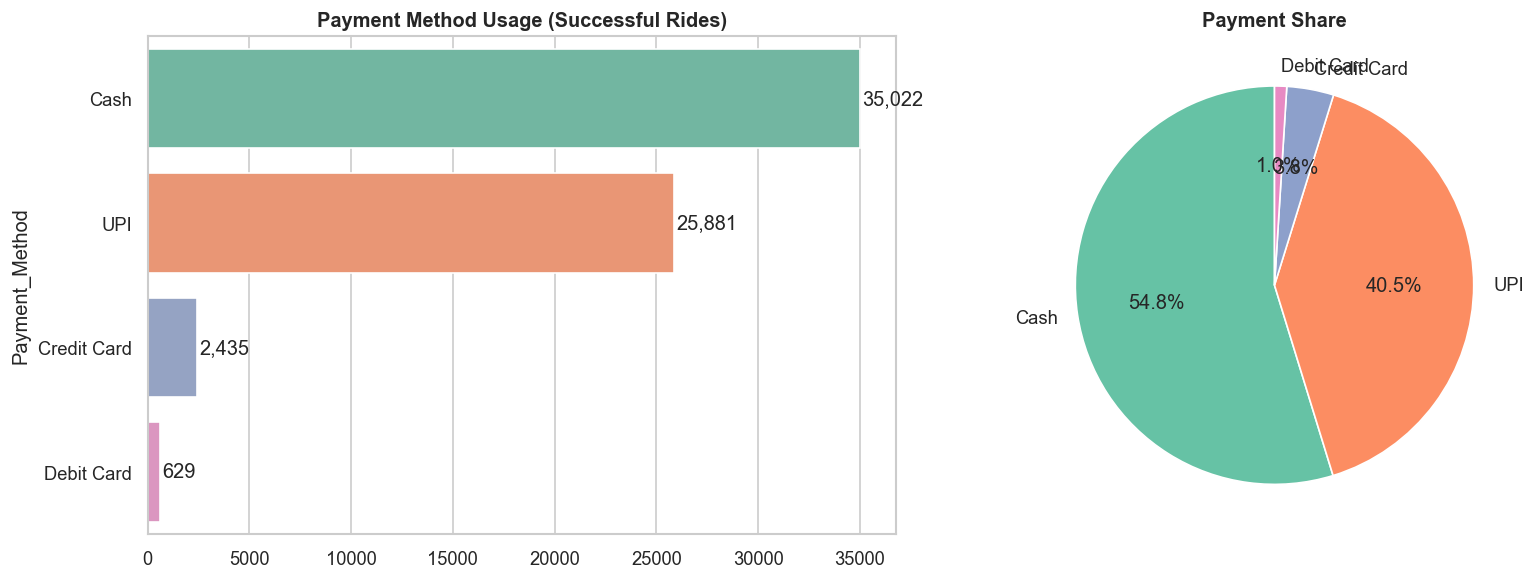


💡 Insight: Cash dominates (~54%). UPI is growing. Credit/Debit card usage is minimal — potential for targeted promotions.


In [31]:
pay = successful['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=pay.values, y=pay.index, ax=ax, hue=pay.index, palette='Set2', legend=False)
ax.set_title('Payment Method Usage (Successful Rides)', fontweight='bold')
for i, v in enumerate(pay.values):
    ax.text(v+100, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()


## Time-Based Trends

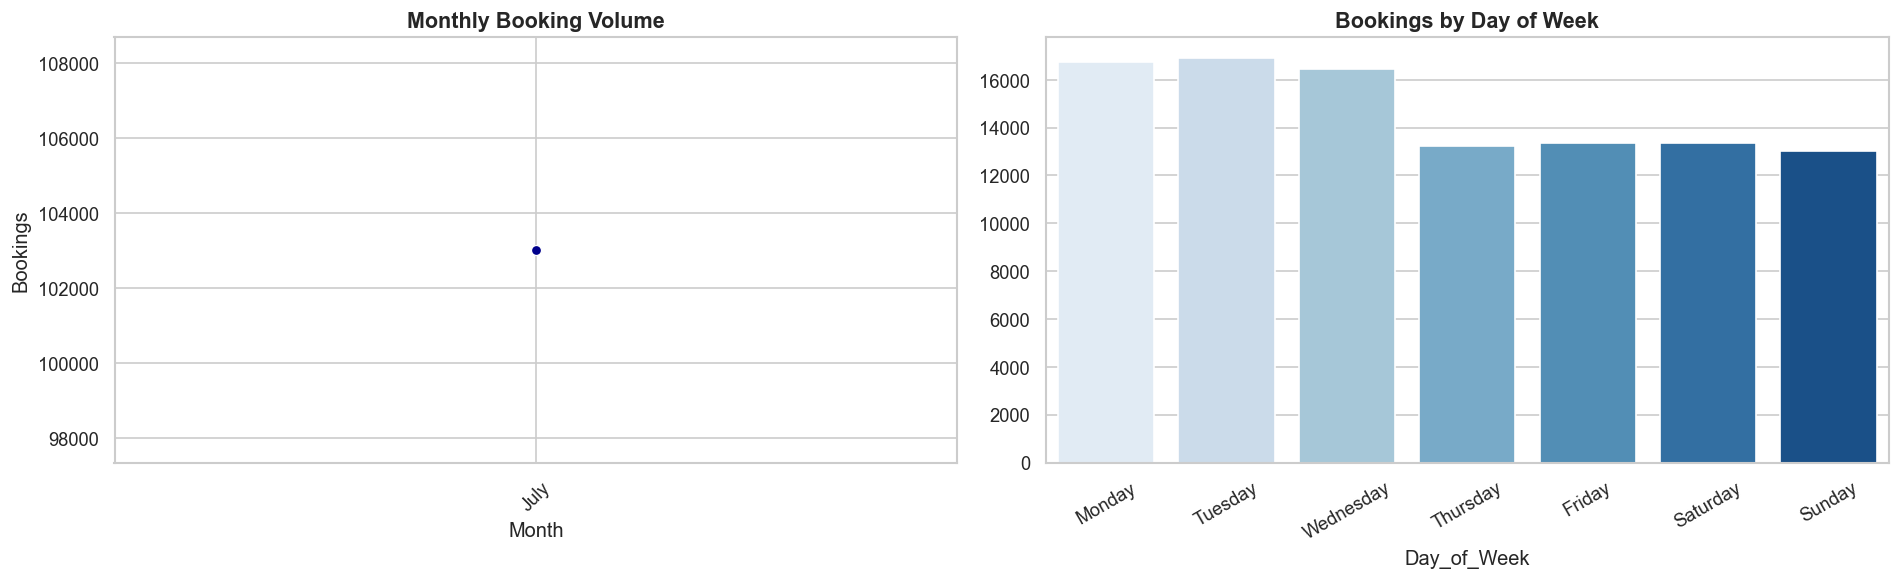

In [32]:
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby('Month')['Booking_ID'].count().reindex(month_order).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='steelblue', ax=ax)
ax.set_title('Monthly Booking Volume', fontweight='bold')
ax.set_ylabel('Bookings')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


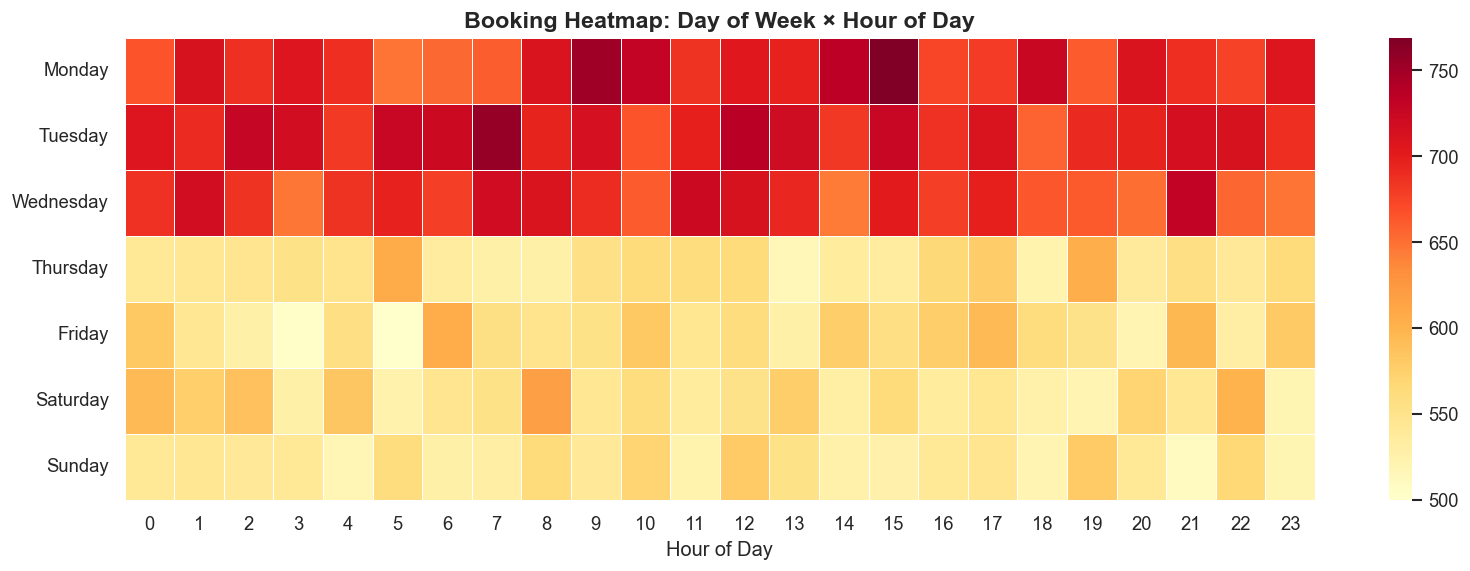


💡 Insight: Evening hours (17:00–21:00) show peak demand across all days — surge pricing opportunity.


In [33]:
# Hourly heatmap by day
pivot = df.groupby(['Day_of_Week','Hour'])['Booking_ID'].count().unstack().reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, annot=False, fmt='d')
plt.title('Booking Heatmap: Day of Week × Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.show()

print("\n💡 Insight: Evening hours (17:00–21:00) show peak demand across all days — surge pricing opportunity.")

## Customer Segmentation (RFM-lite)

      Customer_ID  Frequency  Total_Spend  Avg_Spend           Segment
49134   CID836942          4         6019    1504.75  VIP / High Value
51190   CID868113          2         5986    2993.00  VIP / High Value
39568   CID695232          2         5962    2981.00  VIP / High Value
5044    CID176493          2         5944    2972.00  VIP / High Value
53475   CID902403          2         5938    2969.00  VIP / High Value
48865   CID832844          2         5924    2962.00  VIP / High Value
21014   CID416495          2         5918    2959.00  VIP / High Value
18966   CID384952          2         5918    2959.00  VIP / High Value
51218   CID868427          2         5888    2944.00  VIP / High Value
12009   CID280466          2         5876    2938.00  VIP / High Value


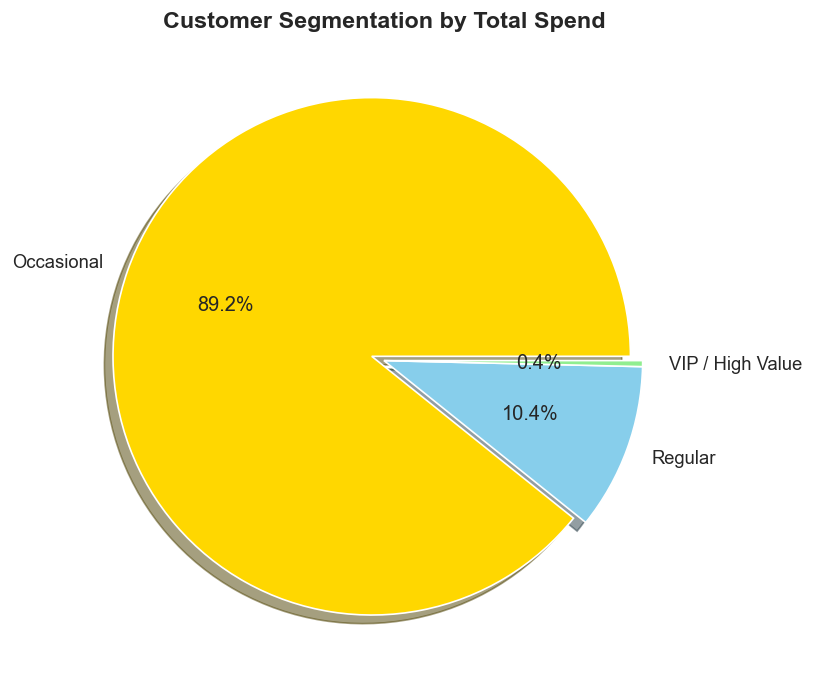


💡 Insight: Identify VIP customers for loyalty rewards; convert 'Occasional' riders with promo codes.


In [34]:
customer = df[df['Booking_Status']=='Success'].groupby('Customer_ID').agg(
    Frequency=('Booking_ID', 'count'),
    Total_Spend=('Booking_Value', 'sum'),
    Avg_Spend=('Booking_Value', 'mean'),
).reset_index()

def segment(spend):
    if spend > 3000: return 'VIP / High Value'
    elif spend > 1000: return 'Regular'
    else: return 'Occasional'

customer['Segment'] = customer['Total_Spend'].apply(segment)
seg_counts = customer['Segment'].value_counts()

print(customer.sort_values('Total_Spend', ascending=False).head(10))

plt.figure(figsize=(7, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        explode=(0.05, 0, 0),
        colors=['#FFD700', '#87CEEB', '#90EE90'], shadow=True)
plt.title('Customer Segmentation by Total Spend', fontsize=14, fontweight='bold')
plt.show()

print("\n💡 Insight: Identify VIP customers for loyalty rewards; convert 'Occasional' riders with promo codes.")

## Top 5 Customers by Ride Count

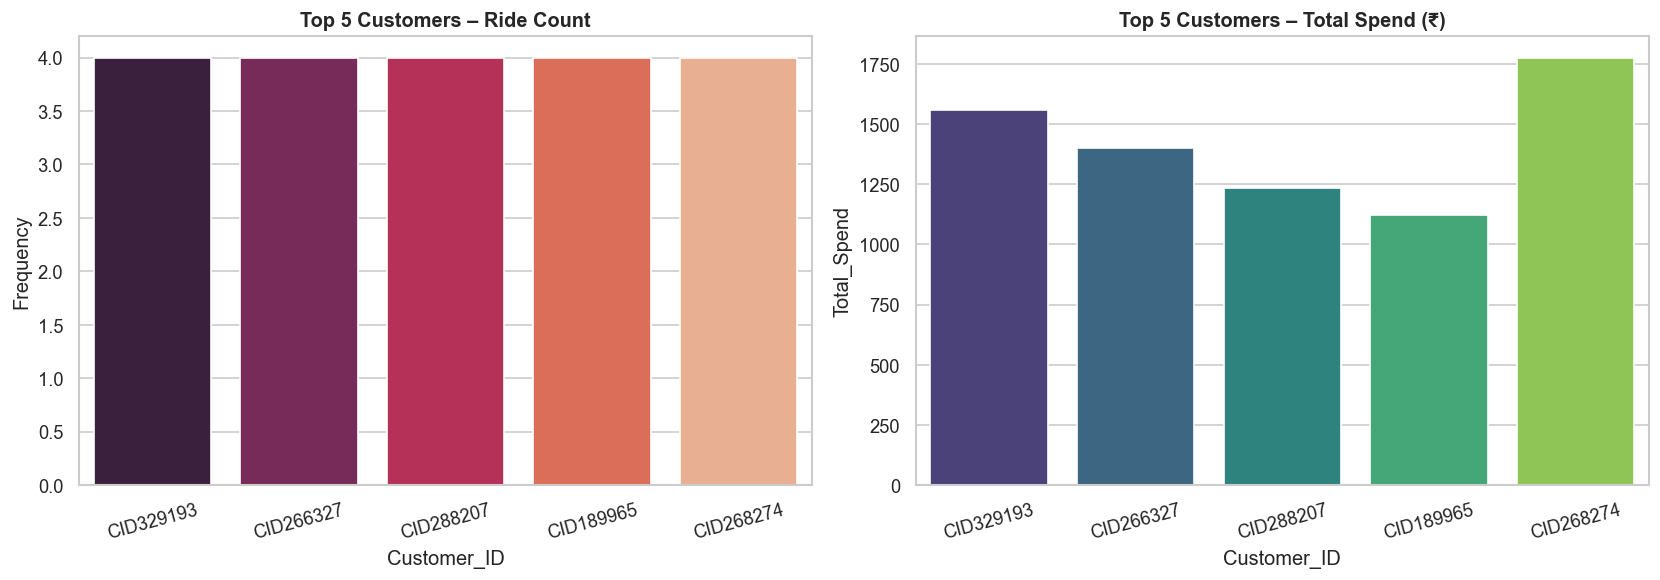

In [35]:
top5 = customer.sort_values('Frequency', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Customer_ID', y='Frequency', data=top5, ax=ax, hue='Customer_ID', palette='rocket', legend=False)
ax.set_title('Top 5 Customers – Ride Count', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## Ratings Analysis

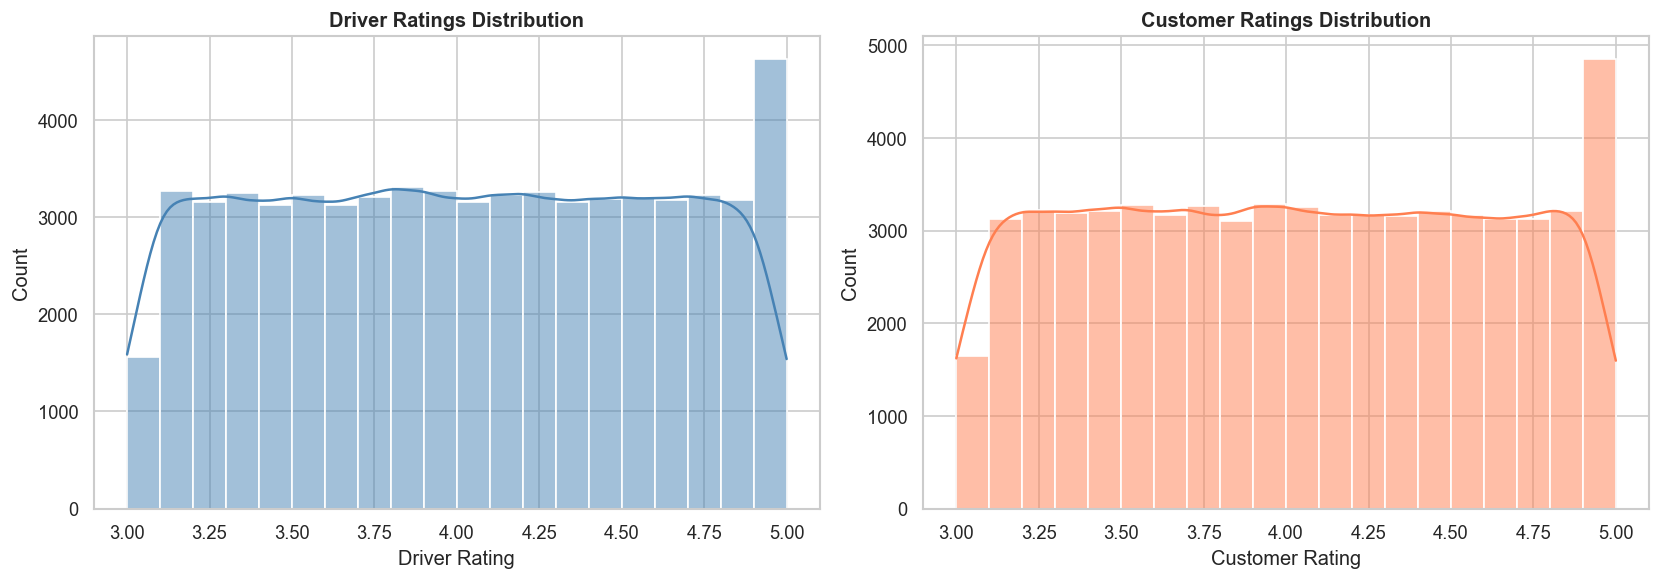

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(successful['Driver_Ratings'].dropna(), bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Driver Ratings Distribution', fontweight='bold')
axes[0].set_xlabel('Driver Rating')

sns.histplot(successful['Customer_Rating'].dropna(), bins=20, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Customer Ratings Distribution', fontweight='bold')
axes[1].set_xlabel('Customer Rating')

plt.tight_layout()
plt.show()

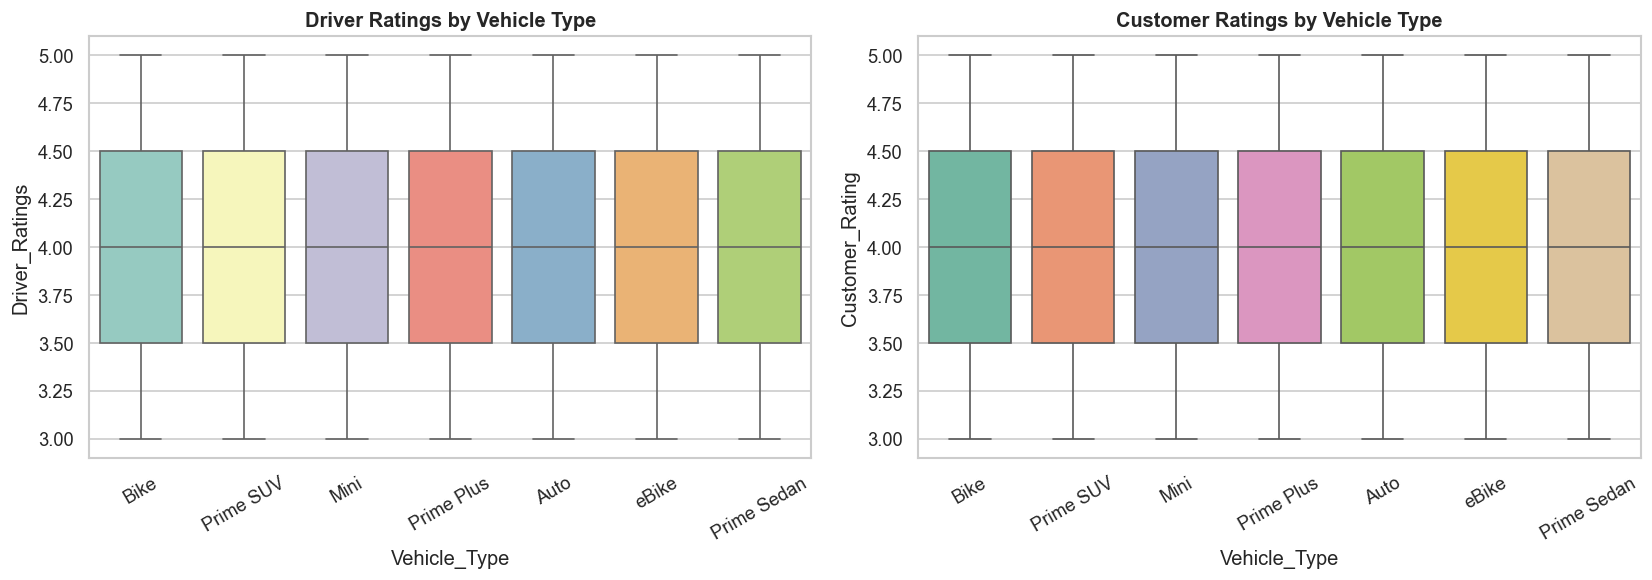

## Incomplete Rides Analysis

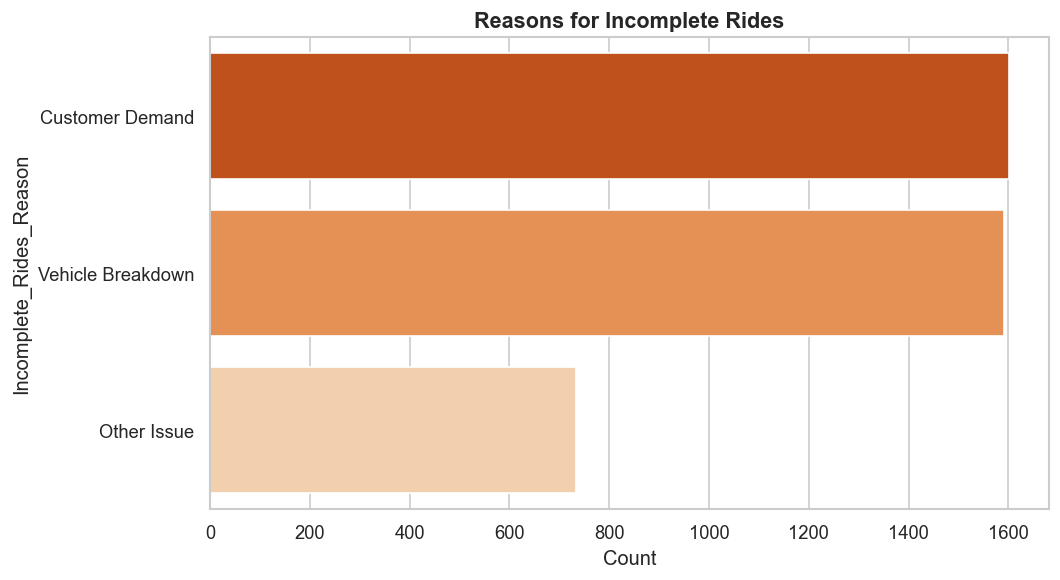


Total Incomplete Rides: 3,926  (3.81% of all bookings)

💡 Insight: Route the most frequent incomplete-ride reasons to driver training or app UX fixes.


In [38]:
incomplete = df[df['Incomplete_Rides'] == 'Yes']
reasons = incomplete['Incomplete_Rides_Reason'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=reasons.values, y=reasons.index, hue=reasons.index, palette='Oranges_r', legend=False)
plt.title('Reasons for Incomplete Rides', fontsize=13, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print(f"\nTotal Incomplete Rides: {len(incomplete):,}  ({len(incomplete)/len(df)*100:.2f}% of all bookings)")
print("\n💡 Insight: Route the most frequent incomplete-ride reasons to driver training or app UX fixes.")

## Statistical Analysis

In [39]:
# ANOVA: Are booking values significantly different across vehicle types?
groups = [grp['Booking_Value'].values for _, grp in successful.groupby('Vehicle_Type')]
f_stat, p_val = f_oneway(*groups)

print(f"One-Way ANOVA — Booking Value across Vehicle Types")
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print("  Conclusion  : Reject H₀ → Booking values differ significantly across vehicle types.")
else:
    print("  Conclusion  : Fail to reject H₀ → No significant difference.")

One-Way ANOVA — Booking Value across Vehicle Types
  F-Statistic : 1.1612
  P-Value     : 0.323881
  Conclusion  : Fail to reject H₀ → No significant difference.


In [ ]:
from scipy.stats import ttest_ind

# Define peak hours as 17–21 based on earlier analysis
peak = successful[successful['Hour'].between(17, 21)]['Ride_Distance']
off_peak = successful[~successful['Hour'].between(17, 21)]['Ride_Distance']

t_stat, p_val = ttest_ind(peak, off_peak, equal_var=False)  # Welch's t-test

print("Independent Samples t-Test — Ride Distance: Peak Hours (17–21) vs Off-Peak")
print(f"  Peak mean     : {peak.mean():.2f} km  (n={len(peak):,})")
print(f"  Off-peak mean : {off_peak.mean():.2f} km  (n={len(off_peak):,})")
print(f"  T-Statistic   : {t_stat:.4f}")
print(f"  P-Value       : {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print(f"  Conclusion    : Reject H0 — ride distances differ significantly between peak and off-peak hours (p < {alpha}).")
else:
    print(f"  Conclusion    : Fail to reject H0 — no significant difference in ride distance between peak and off-peak hours (p >= {alpha}).")


In [ ]:
plot_df = successful.copy()
plot_df['Period'] = plot_df['Hour'].apply(lambda h: 'Peak (17–21)' if 17 <= h <= 21 else 'Off-Peak')

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Period', y='Ride_Distance', data=plot_df, ax=ax,
            palette={'Peak (17–21)': '#e74c3c', 'Off-Peak': '#3498db'},
            width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Ride Distance Distribution: Peak vs Off-Peak', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Ride Distance (km)')
ax.annotate(f'p = {p_val:.4f}', xy=(0.5, 0.95), xycoords='axes fraction',
            ha='center', fontsize=10, color='green' if p_val < 0.05 else 'red', fontstyle='italic')
plt.tight_layout()
plt.show()


Chi-Square Test — Payment Method × Vehicle Type
  Chi2 Stat : 14.92
  P-Value   : 0.667785
  DOF       : 18


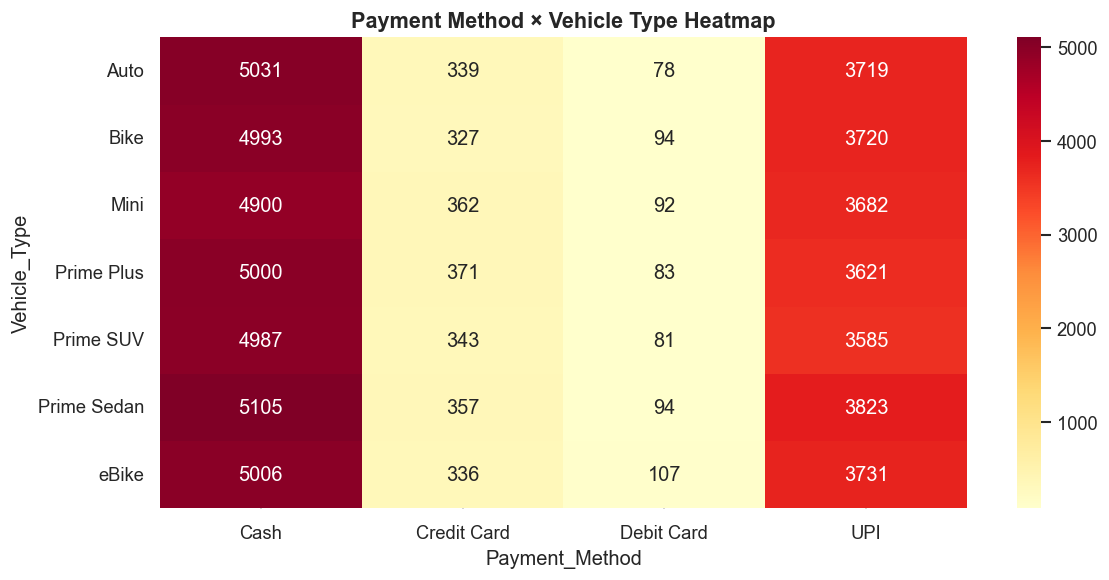

In [40]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(successful['Vehicle_Type'], successful['Payment_Method'])
chi2, p_val_chi, dof, expected = chi2_contingency(contingency)

print(f"Chi-Square Test — Payment Method x Vehicle Type")
print(f"  Chi2 Stat : {chi2:.2f}")
print(f"  P-Value   : {p_val_chi:.6f}")
print(f"  DOF       : {dof}")
if p_val_chi < 0.05:
    print("  Conclusion: Significant association between vehicle type and payment method.")
else:
    print("  Conclusion: No significant association found.")


## Correlation Matrix (Successful Rides)

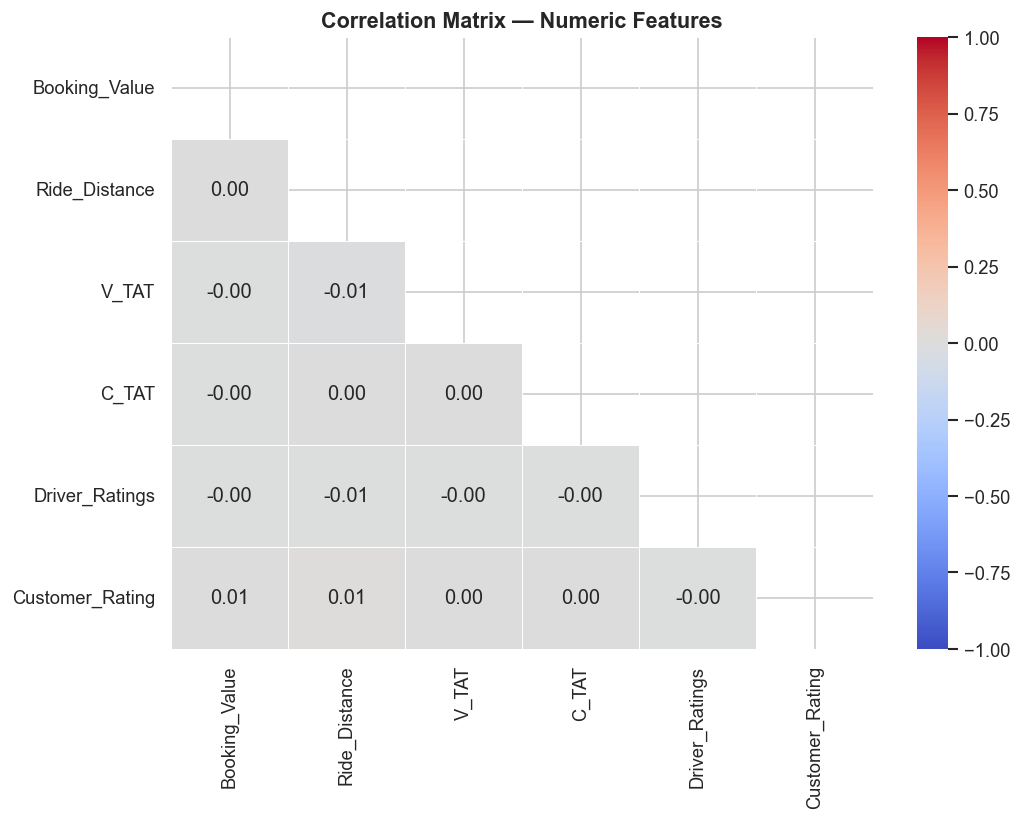


💡 Insight: Ride_Distance and Booking_Value are positively correlated — distance is a strong pricing driver.


In [41]:
num_cols = ['Booking_Value', 'Ride_Distance', 'V_TAT', 'C_TAT', 'Driver_Ratings', 'Customer_Rating']
corr = successful[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Ride_Distance and Booking_Value are positively correlated — distance is a strong pricing driver.")

## Vehicle Type Scorecard

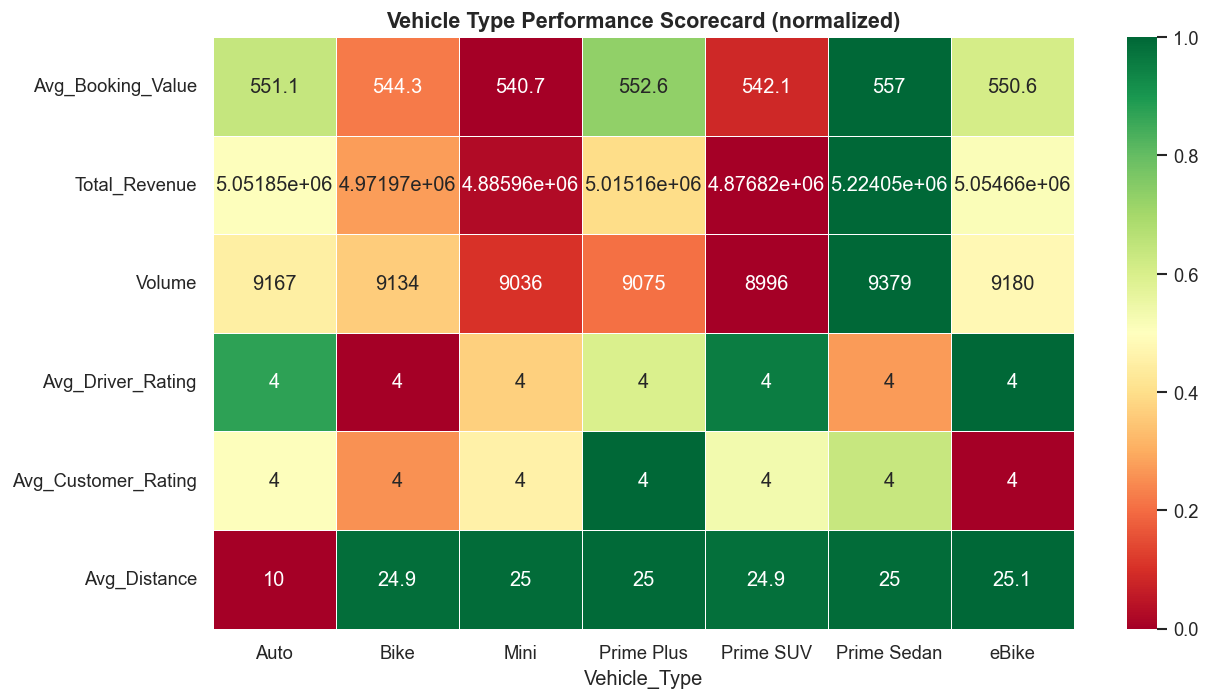

In [42]:
scorecard = successful.groupby('Vehicle_Type').agg(
    Avg_Booking_Value=('Booking_Value', 'mean'),
    Total_Revenue=('Booking_Value', 'sum'),
    Volume=('Booking_ID', 'count'),
    Avg_Driver_Rating=('Driver_Ratings', 'mean'),
    Avg_Customer_Rating=('Customer_Rating', 'mean'),
    Avg_Distance=('Ride_Distance', 'mean'),
)

scorecard_norm = (scorecard - scorecard.min()) / (scorecard.max() - scorecard.min())

plt.figure(figsize=(11, 6))
sns.heatmap(scorecard_norm.T, annot=scorecard.T.round(1), fmt='g',
            cmap='RdYlGn', linewidths=0.5, linecolor='white')
plt.title('Vehicle Type Performance Scorecard (normalized)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Insights Summary

| # | Finding | Action |
|---|---------|--------|
| 1 | **62% booking success rate** 18% cancelled by drivers | Reduce driver-side cancellations via incentives & penalties |
| 2 | **Evening hours (1721)** drive peak demand | Enable dynamic surge pricing in those slots |
| 3 | **Prime SUV/Sedan** have the highest avg booking value | Premium fleet expansion could increase revenue |
| 4 | **Cash dominates (54%)** UPI at 40% | Push UPI cashback offers to accelerate digital shift |
| 5 | **Driver ratings are uniformly high** (>4.0) | Investigate if rating system is gamed; A/B test new flows |
| 6 | **Ride distance strongly drives booking value** | Use distance-based pricing models |
| 7 | **VIP customers (high spend)** are a small % | Build loyalty programme targeting top 10% spenders |
